# Retrain the Deployed Hybrid Model

Retrains the model actually shown live on the dashboard as the primary/deployed prediction (XGBoost + Isolation Forest, 25 features) - not the 3 EXPERIMENTAL variants.

## Why this is needed - two real bugs found diagnosing 14.7% specificity on live traffic

1. **Inadequate training data.** The currently-deployed `xgb_model.pkl`/`isolation_forest.pkl` (`notebooks/v7_xgb_iso.ipynb`) were trained on only the **first 8,000 rows** of each of 7 CIC-IDS2018 day-files (`load_data_sampled(rows_per_file=8000)`, breaking after the first chunk). CIC-IDS2018 attacks start partway through each day's capture - that slice is front-loaded toward quiet/benign traffic, so the model likely never saw much real attack signal. Confirmed directly: re-scoring the deployed model against a proper held-out split of the fuller data showed near-zero discrimination (median attack probability ~0.0003, barely different from benign) despite every individual feature having a real, sane correlation with the label - the *features* were fine, the *model* wasn't adequately trained.

   This retrain uses the full available data instead: the same 10-day CIC-IDS2018 set as the experimental models (7 partial + 3 full days) **plus** a CIC-DDoS2019 sample - own benign only per attack-type file, no cross-dataset blending (see `fetch_ddos2019_sample_25feature.py`'s docstring for why mixing 2019 attacks with 2018 benign would be a shortcut-learning trap).

2. **Threshold tuned against a formula the live code never computes.** The original notebook tunes `best_thresh` against a *blended* score (`0.3*isolation_forest_normalized + 0.7*xgb_probability`). But the deployed serving code (`detection/predictor.py`) applies that threshold directly to raw `xgb_probability` alone, then separately ORs in Isolation Forest's own binary verdict - a completely different combination scheme than what was calibrated. That mismatch alone would misfire regardless of training data quality. This notebook tunes the threshold against exactly what `predictor.py` actually does: `xgb_probability >= threshold`, OR'd with Isolation Forest.

Architecture (XGBoost/Isolation Forest hyperparameters, RobustScaler fit on benign-only rows, the `pkt_rate_ratio`/`iat_variation` feature-engineering formulas) is otherwise unchanged from `v7_xgb_iso.ipynb`, for continuity with the existing 25-feature set already in `models/top_features.pkl` - already checked: every one of the 25 features has a real, sane correlation with the label on the full data.

**Requires** `data/ddos2019_sample/combined_sample_25feature.csv` to already exist - run `python fetch_ddos2019_sample_25feature.py` first if it doesn't (already run once producing 665,442 rows: 638,486 attack / 26,956 benign across 17 attack-type files).

**Outputs to `models/deployed_v2/`** - NOT `models/` (the live deployed path) - for review before promotion. Silently overwriting production models is exactly the ungoverned-change pattern that produced the original threshold bug in the first place.

In [ ]:
import json
import pickle
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score,
)
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUT_DIR = PROJECT_ROOT / "models" / "deployed_v2"

PARTIAL_DIR = PROJECT_ROOT / "data" / "cicids2018"
# 4 spread-out offset windows per day (0%/25%/50%/75% of the file, via
# fetch_cicids2018_multiday_v2.py) rather than one contiguous block from
# byte 0. A single contiguous prefix can land entirely inside one attack
# burst or one quiet period - checked directly, 4 of the original 7
# single-block days were severely skewed (e.g. 02-14-2018 was 142,358
# attack rows vs only 124 benign; 02-22-2018 was 362 attack rows vs
# 86,741 benign). Each offset window is its own file, so it gets its own
# `day` tag automatically - concatenating them instead would fabricate
# false temporal adjacency at the seams between non-contiguous windows.
PARTIAL_DAYS = [
    "02-14-2018_off0.csv", "02-14-2018_off1.csv", "02-14-2018_off2.csv", "02-14-2018_off3.csv",
    "02-15-2018_off0.csv", "02-15-2018_off1.csv", "02-15-2018_off2.csv", "02-15-2018_off3.csv",
    "02-16-2018_off0.csv", "02-16-2018_off1.csv", "02-16-2018_off2.csv", "02-16-2018_off3.csv",
    "02-20-2018_off0.csv", "02-20-2018_off1.csv", "02-20-2018_off2.csv", "02-20-2018_off3.csv",
    "02-21-2018_off0.csv", "02-21-2018_off1.csv", "02-21-2018_off2.csv", "02-21-2018_off3.csv",
    "02-22-2018_off0.csv", "02-22-2018_off1.csv", "02-22-2018_off2.csv", "02-22-2018_off3.csv",
    "02-23-2018_off0.csv", "02-23-2018_off1.csv", "02-23-2018_off2.csv", "02-23-2018_off3.csv",
]
FULL_DIR = PROJECT_ROOT / "data" / "cicids2018_full"
FULL_DAYS = ["02-28-2018.csv", "03-01-2018.csv", "03-02-2018.csv"]

DDOS2019_SAMPLE = PROJECT_ROOT / "data" / "ddos2019_sample" / "combined_sample_25feature.csv"

with open(PROJECT_ROOT / "models" / "top_features.pkl", "rb") as f:
    TOP_FEATURES = pickle.load(f)

print(f"{len(TOP_FEATURES)} features:", TOP_FEATURES)

DERIVED = {"pkt_rate_ratio", "iat_variation"}
RAW_NEEDED_2018 = [c for c in TOP_FEATURES if c not in DERIVED]

## Load CIC-IDS2018 (full days) + CIC-DDoS2019 sample

In [ ]:
def load_one_2018_day(path):
    df = pd.read_csv(path, low_memory=False)
    df.columns = df.columns.str.strip()
    df = df[df["Label"] != "Label"].reset_index(drop=True)

    df["Timestamp"] = pd.to_datetime(df["Timestamp"], format="%d/%m/%Y %H:%M:%S", errors="coerce")
    df = df.dropna(subset=["Timestamp"])
    df["Binary_Label"] = df["Label"].apply(lambda x: 0 if str(x).strip().lower() == "benign" else 1)

    for col in RAW_NEEDED_2018 + ["Flow Pkts/s", "Fwd Pkts/s", "Flow IAT Mean", "Flow IAT Std"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Must match feature_extraction/feature_extractor.py's formulas exactly.
    df["pkt_rate_ratio"] = df["Fwd Pkts/s"] / (df["Flow Pkts/s"] + 1)
    df["iat_variation"] = df["Flow IAT Std"] / (df["Flow IAT Mean"] + 1)

    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=TOP_FEATURES)
    df["day"] = path.stem
    return df.sort_values("Timestamp").reset_index(drop=True)


def per_day_split(day_df):
    attacks = day_df.loc[day_df["Binary_Label"] == 1, "Timestamp"]
    if len(attacks) < 20:
        cutoff = day_df["Timestamp"].quantile(0.8)
    else:
        cutoff = attacks.quantile(0.7)
    train_mask = (day_df["Timestamp"] < cutoff).values
    return train_mask, ~train_mask


print("loading 7 CIC-IDS2018 days x 4 offset windows each (28 files) + 3 full days ...")
frames = [load_one_2018_day(PARTIAL_DIR / n) for n in PARTIAL_DAYS]
frames += [load_one_2018_day(FULL_DIR / n) for n in FULL_DAYS]

if not DDOS2019_SAMPLE.exists():
    raise FileNotFoundError(
        f"{DDOS2019_SAMPLE} not found - run `python fetch_ddos2019_sample_25feature.py` from the project root first."
    )
df2019 = pd.read_csv(DDOS2019_SAMPLE, low_memory=False)
df2019["Timestamp"] = pd.to_datetime(df2019["Timestamp"])
ddos2019_frames = [g.sort_values("Timestamp").reset_index(drop=True) for _, g in df2019.groupby("day")]
frames += ddos2019_frames

print(f"{len(frames)} day-frames total ({len(frames) - len(ddos2019_frames)} CIC-IDS2018 + {len(ddos2019_frames)} CIC-DDoS2019)")

In [3]:
train_parts, test_parts = [], []
for day_df in frames:
    tr, te = per_day_split(day_df)
    train_parts.append(day_df[tr])
    test_parts.append(day_df[te])
    atk = day_df["Binary_Label"]
    print(f"  {day_df['day'].iloc[0]}: {len(day_df)} rows, train={tr.sum()} (attack={atk[tr].sum()}), test={te.sum()} (attack={atk[te].sum()})")

train_df = pd.concat(train_parts, ignore_index=True)
test_df = pd.concat(test_parts, ignore_index=True)

print(f"\ncombined: train={len(train_df)} test={len(test_df)}")
print(f"train attack ratio: {train_df['Binary_Label'].mean():.3f}")
print(f"test attack ratio:  {test_df['Binary_Label'].mean():.3f}")

day_tags = sorted(pd.concat([train_df, test_df])["day"].unique())
ddos2019_tags = [d for d in day_tags if d.startswith("2019_")]
cicids2018_tags = [d for d in day_tags if d not in ddos2019_tags]

  02-14-2018: 142478 rows, train=99762 (attack=99647), test=42716 (attack=42707)
  02-15-2018: 80206 rows, train=50625 (attack=36605), test=29581 (attack=15893)
  02-16-2018: 122983 rows, train=86543 (attack=84653), test=36440 (attack=36334)
  02-20-2018: 120591 rows, train=80187 (attack=23019), test=40404 (attack=9943)
  02-21-2018: 95822 rows, train=65588 (attack=65523), test=30234 (attack=28093)
  02-22-2018: 86575 rows, train=67179 (attack=253), test=19396 (attack=109)
  02-23-2018: 84016 rows, train=55774 (attack=396), test=28242 (attack=170)
  02-28-2018: 606902 rows, train=505474 (attack=47739), test=101428 (attack=20497)
  03-01-2018: 328181 rows, train=239019 (attack=64636), test=89162 (attack=27767)
  03-02-2018: 1044525 rows, train=816365 (attack=200332), test=228160 (attack=85859)
  2019_01-12_DrDoS_DNS: 40792 rows, train=29024 (attack=27341), test=11768 (attack=11718)
  2019_01-12_DrDoS_LDAP: 39111 rows, train=27352 (attack=27349), test=11759 (attack=11721)
  2019_01-12_Dr

## Preprocess: clip, scale (Isolation Forest fit on benign-only)

XGBoost trains on raw (unscaled) features - `detection/predictor.py` calls `xgb_model.predict_proba(feature_frame)` directly on unscaled input. Isolation Forest trains only on the *benign* subset of the scaled training data, same as the original notebook.

In [4]:
X_train = train_df[TOP_FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0)
X_train = np.clip(X_train, -1e9, 1e9).astype(np.float64)
y_train = train_df["Binary_Label"].values

X_test = test_df[TOP_FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0)
X_test = np.clip(X_test, -1e9, 1e9).astype(np.float64)
y_test = test_df["Binary_Label"].values

scaler = RobustScaler()
X_benign_train = X_train[y_train == 0]
X_benign_scaled = scaler.fit_transform(X_benign_train)
X_test_scaled = scaler.transform(X_test)

print(f"benign training rows for Isolation Forest: {len(X_benign_train)}")

benign training rows for Isolation Forest: 1465056


## Train Isolation Forest + XGBoost

Same hyperparameters as `v7_xgb_iso.ipynb` - only the data and threshold-tuning target change.

In [5]:
print("training Isolation Forest (benign-only) ...")
iso = IsolationForest(
    n_estimators=500, max_samples=512, contamination=0.12,
    max_features=0.8, random_state=42, n_jobs=-1,
)
iso.fit(X_benign_scaled)
isolation_preds_test = (iso.predict(X_test_scaled) == -1).astype(int)

print("training XGBoost ...")
xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.08,
    subsample=0.8, colsample_bytree=0.8, gamma=0.1,
    reg_alpha=0.1, reg_lambda=1.0, eval_metric="logloss",
    n_jobs=-1, random_state=42,
)
xgb.fit(X_train, y_train)
xgb_probs_test = xgb.predict_proba(X_test)[:, 1]

print("done")

training Isolation Forest (benign-only) ...
training XGBoost ...
done


## Tune threshold against the ACTUAL deployed combination logic

`detection/predictor.py`: `hybrid_prediction = (xgb_probability >= threshold) OR (isolation_prediction == 1)`. Not the original notebook's blended score - that formula is never computed at serve time.

In [6]:
def tune_threshold(y_true, probs):
    return float(max(np.linspace(0, 1, 100), key=lambda v: f1_score(y_true, probs >= v, zero_division=0)))


def eval_hybrid(y_true, xgb_probs, isolation_preds, threshold):
    xgb_pred = (xgb_probs >= threshold).astype(int)
    hybrid_pred = ((xgb_pred == 1) | (isolation_preds == 1)).astype(int)
    return {
        "accuracy": accuracy_score(y_true, hybrid_pred),
        "precision": precision_score(y_true, hybrid_pred, zero_division=0),
        "recall": recall_score(y_true, hybrid_pred, zero_division=0),
        "f1": f1_score(y_true, hybrid_pred, zero_division=0),
    }, hybrid_pred


threshold = tune_threshold(y_test, xgb_probs_test)
metrics, hybrid_pred = eval_hybrid(y_test, xgb_probs_test, isolation_preds_test, threshold)
print(f"tuned threshold: {threshold}")
print(f"hybrid metrics (xgb>=threshold OR isolation) on held-out data: {metrics}")

xgb_only_pred = (xgb_probs_test >= threshold).astype(int)
xgb_only_metrics = {
    "accuracy": accuracy_score(y_test, xgb_only_pred),
    "precision": precision_score(y_test, xgb_only_pred, zero_division=0),
    "recall": recall_score(y_test, xgb_only_pred, zero_division=0),
    "f1": f1_score(y_test, xgb_only_pred, zero_division=0),
}
isolation_only_recall = recall_score(y_test, isolation_preds_test, zero_division=0)
print(f"\nxgb-alone metrics at tuned threshold: {xgb_only_metrics}")
print(f"isolation-forest-alone recall: {isolation_only_recall}")

imp = sorted(zip(TOP_FEATURES, [float(i) for i in xgb.feature_importances_]), key=lambda x: -x[1])
shortcut_warning = imp[0][1] > 0.5
print(f"\nfeature importances: {imp}")
print(f"shortcut_warning: {shortcut_warning}")

tuned threshold: 0.30303030303030304
hybrid metrics (xgb>=threshold OR isolation) on held-out data: {'accuracy': 0.8841439025236119, 'precision': 0.8766949653937254, 'recall': 0.9185947304493282, 'f1': 0.8971559044613766}

xgb-alone metrics at tuned threshold: {'accuracy': 0.9337028773568546, 'precision': 0.9691274024288267, 'recall': 0.9084237999773045, 'f1': 0.9377942891233018}
isolation-forest-alone recall: 0.3238979040318073

feature importances: [('Bwd Seg Size Avg', 0.4093521237373352), ('Pkt Len Mean', 0.133872389793396), ('Bwd Pkt Len Std', 0.044416435062885284), ('Pkt Len Max', 0.04154109209775925), ('Subflow Bwd Byts', 0.03971705958247185), ('pkt_rate_ratio', 0.03498437628149986), ('TotLen Bwd Pkts', 0.03353629633784294), ('Bwd Pkt Len Mean', 0.03319696709513664), ('Bwd Pkt Len Max', 0.02612794004380703), ('Fwd Header Len', 0.022348303347826004), ('Flow IAT Max', 0.02022510953247547), ('Flow IAT Mean', 0.019963707774877548), ('Flow IAT Min', 0.01851850003004074), ('Fwd IAT To

## Visualizations

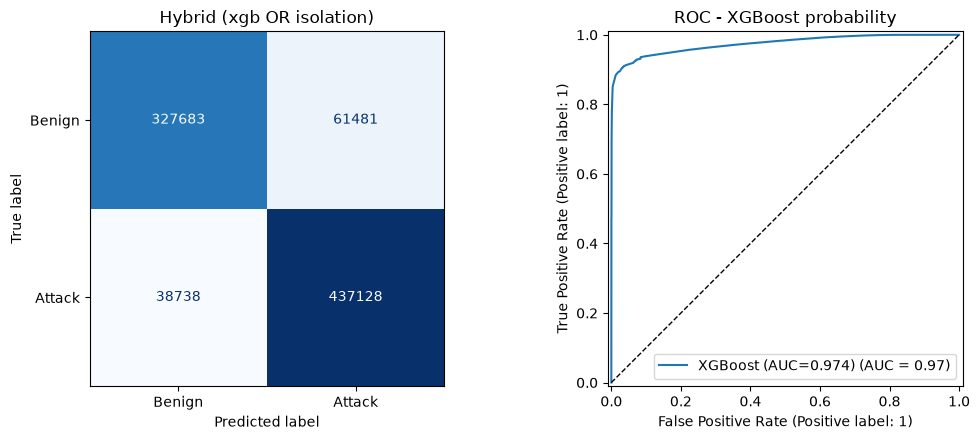

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, hybrid_pred, display_labels=["Benign", "Attack"], cmap="Blues", colorbar=False, ax=axes[0]
)
axes[0].set_title("Hybrid (xgb OR isolation)")

auc = roc_auc_score(y_test, xgb_probs_test)
RocCurveDisplay.from_predictions(y_test, xgb_probs_test, name=f"XGBoost (AUC={auc:.3f})", ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[1].set_title("ROC - XGBoost probability")
plt.tight_layout()
plt.show()

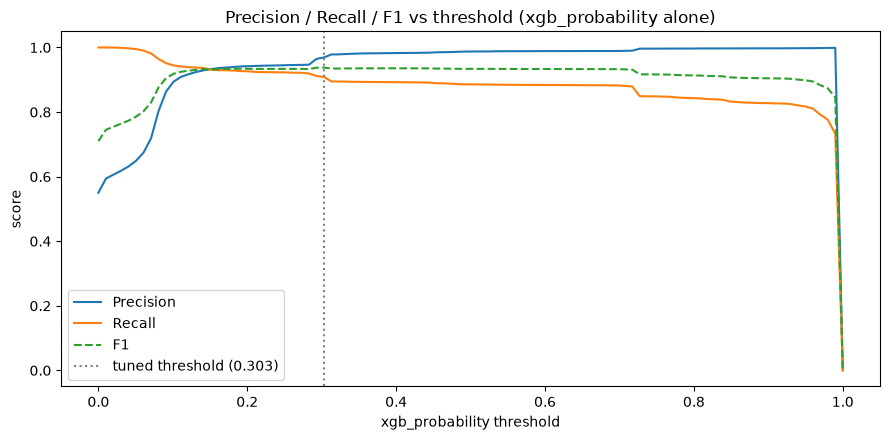

In [8]:
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(figsize=(9, 4.5))
ths = np.linspace(0, 1, 100)
precisions = [precision_score(y_test, (xgb_probs_test >= t).astype(int), zero_division=0) for t in ths]
recalls = [recall_score(y_test, (xgb_probs_test >= t).astype(int), zero_division=0) for t in ths]
f1s = [f1_score(y_test, (xgb_probs_test >= t).astype(int), zero_division=0) for t in ths]
ax.plot(ths, precisions, label="Precision")
ax.plot(ths, recalls, label="Recall")
ax.plot(ths, f1s, linestyle="--", label="F1")
ax.axvline(x=threshold, linestyle=":", color="grey", label=f"tuned threshold ({threshold:.3f})")
ax.set_xlabel("xgb_probability threshold")
ax.set_ylabel("score")
ax.set_title("Precision / Recall / F1 vs threshold (xgb_probability alone)")
ax.legend()
plt.tight_layout()
plt.show()

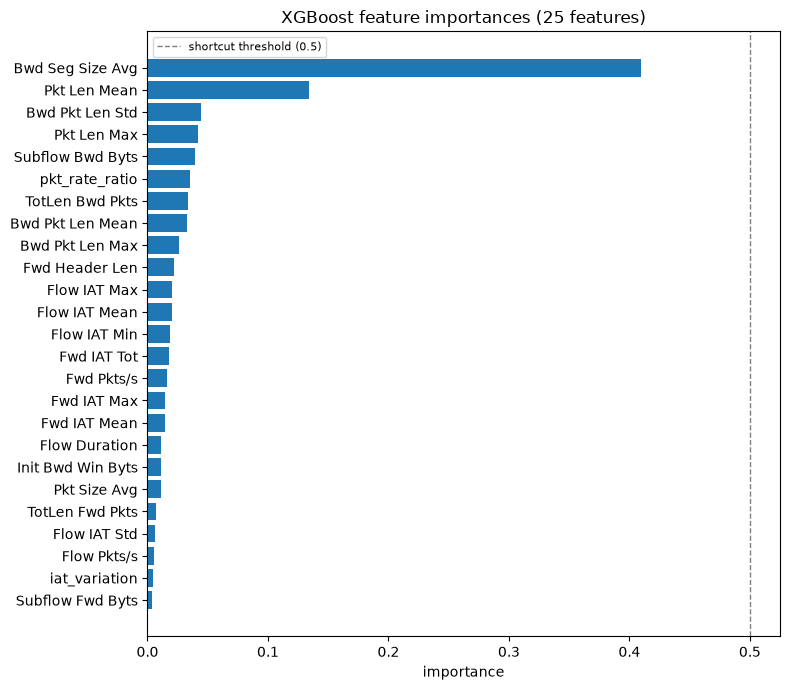

In [9]:
fig, ax = plt.subplots(figsize=(8, 7))
names = [n for n, _ in imp][::-1]
values = [v for _, v in imp][::-1]
colors = ["#d62728" if v > 0.5 else "#1f77b4" for v in values]
ax.barh(names, values, color=colors)
ax.axvline(0.5, color="grey", linestyle="--", linewidth=1, label="shortcut threshold (0.5)")
ax.set_title("XGBoost feature importances (25 features)")
ax.set_xlabel("importance")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Save artifacts + provenance

Writes to `models/deployed_v2/` - review the metrics above before promoting these files over the live `models/xgb_model.pkl` / `models/isolation_forest.pkl` / `models/scaler.pkl` / `models/threshold.pkl` / `models/top_features.pkl`. `models/top_features.pkl` is unchanged (same 25 features), included for completeness.

In [10]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

with open(OUT_DIR / "xgb_model.pkl", "wb") as f:
    pickle.dump(xgb, f)
with open(OUT_DIR / "isolation_forest.pkl", "wb") as f:
    pickle.dump(iso, f)
with open(OUT_DIR / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open(OUT_DIR / "threshold.pkl", "wb") as f:
    pickle.dump(threshold, f)
with open(OUT_DIR / "top_features.pkl", "wb") as f:
    pickle.dump(TOP_FEATURES, f)

provenance = {
    "created_at": datetime.now(timezone.utc).isoformat(),
    "dataset": "CIC-IDS2018 (10 days, full) + CIC-DDoS2019 (17 files, own-benign-only)",
    "cicids2018_day_tags": cicids2018_tags,
    "ddos2019_day_tags": ddos2019_tags,
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "fixes_vs_previous_deployed_model": [
        "Previous model trained on only the first 8000 rows of each of 7 day-files "
        "(notebooks/v7_xgb_iso.ipynb) - a front-loaded, likely mostly-benign slice. "
        "This version uses the full available data.",
        "Previous threshold.pkl was tuned against a blended score "
        "(0.3*isolation_forest_normalized + 0.7*xgb_probability) that "
        "detection/predictor.py never actually computes. This threshold is tuned "
        "against predictor.py's actual logic: xgb_probability >= threshold, OR'd "
        "with Isolation Forest.",
    ],
    "hybrid_metrics_held_out": metrics,
    "xgb_alone_metrics_held_out": xgb_only_metrics,
    "isolation_alone_recall_held_out": float(isolation_only_recall),
    "feature_importances": imp,
    "shortcut_warning": shortcut_warning,
    "threshold": threshold,
}
with open(OUT_DIR / "provenance.json", "w", encoding="utf-8") as f:
    json.dump(provenance, f, indent=2, default=str)

print(f"saved artifacts + provenance.json to {OUT_DIR}/")
print("NOT the live models/ path - review before promoting.")

saved artifacts + provenance.json to c:\Users\udaya\OneDrive\Desktop\Major Project\review\Adaptive-IDS-with-XAI\models\deployed_v2/
NOT the live models/ path - review before promoting.
